[+] Data Loaded. Shape: (1256, 4)
[~] Simulating 1000 paths for 4 assets over 1 year(s)...


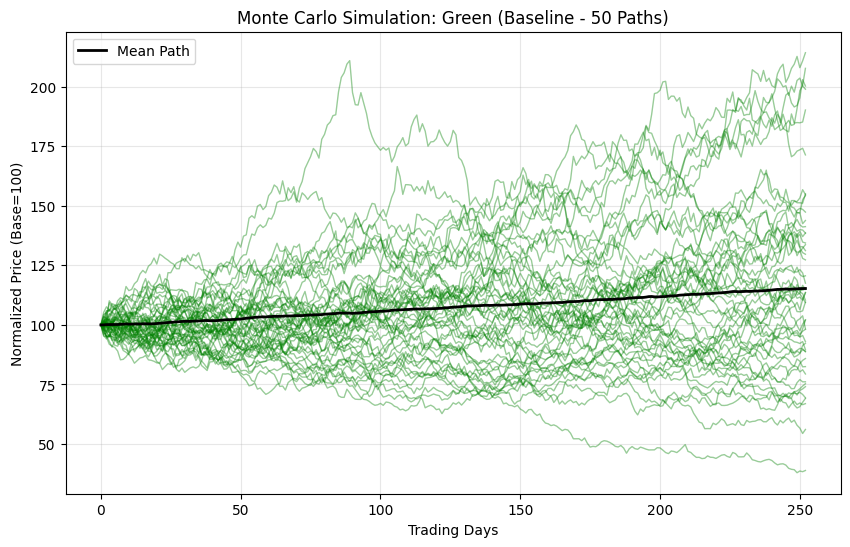

[+] Simulation Complete. Output Shape: (1000, 253, 4)
[+] Correlation Matrix (Check):
         Oil  Green  Market  Brown
Oil     1.00   0.21    0.26   0.50
Green   0.21   1.00    0.70   0.48
Market  0.26   0.70    1.00   0.63
Brown   0.50   0.48    0.63   1.00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Path Setup ---
current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

# Load the processed data from Phase 1
data_path = os.path.join(PROJECT_ROOT, "data", "processed", "market_returns.csv")
returns_df = pd.read_csv(data_path, index_col=0)

print(f"[+] Data Loaded. Shape: {returns_df.shape}")

# --- 2. The Monte Carlo Engine Class ---

class MonteCarloEngine:
    def __init__(self, returns_data):
        self.returns = returns_data
        self.assets = returns_data.columns
        self.n_assets = len(self.assets)
        
        # Calibration (Annualized)
        # We assume 252 trading days per year
        self.mu = self.returns.mean() * 252
        self.cov_matrix = self.returns.cov() * 252
        
        # Cholesky Decomposition for Correlated Shocks
        # Decomposes Covariance Matrix Sigma into L * L.T
        self.L = np.linalg.cholesky(self.cov_matrix)
        
    def simulate(self, T_years=1, n_scenarios=1000, dt=1/252):
        """
        Simulates future price paths using Multivariate Geometric Brownian Motion.
        
        Parameters:
        - T_years: Time horizon (1 year)
        - n_scenarios: Number of Monte Carlo paths
        - dt: Time step (1 day)
        """
        n_steps = int(T_years / dt)
        
        # Storage for all paths: Shape (Scenarios, Steps, Assets)
        # We start at "100" as a normalized index base
        paths = np.zeros((n_scenarios, n_steps + 1, self.n_assets))
        paths[:, 0, :] = 100 
        
        print(f"[~] Simulating {n_scenarios} paths for {self.n_assets} assets over {T_years} year(s)...")
        
        for t in range(1, n_steps + 1):
            # 1. Generate Uncorrelated Random Shocks (Standard Normal)
            # Shape: (n_scenarios, n_assets)
            Z_uncorr = np.random.normal(0, 1, size=(n_scenarios, self.n_assets))
            
            # 2. Correlate the Shocks using Cholesky Matrix L
            # Z_corr = Z_uncorr @ L.T
            Z_corr = Z_uncorr @ self.L.T
            
            # 3. Apply GBM Formula: S_t = S_{t-1} * exp( (mu - 0.5*sigma^2)*dt + sigma*Z*sqrt(dt) )
            # We use the vector form for efficiency
            
            # Drift term: (mu - 0.5 * var) * dt
            drift = (self.mu.values - 0.5 * np.diag(self.cov_matrix)) * dt
            
            # Diffusion term: sigma * dW (We already have correlated volatility in Z_corr)
            # Note: self.L includes the volatility magnitude, so Z_corr is effectively (sigma * Z)
            # However, for clarity in GBM derivation:
            # We typically model dS/S. Let's stick to the exponent form for geometric stability.
            
            # Re-calculating diffusion explicitly from covariance logic:
            diffusion = Z_corr * np.sqrt(dt)
            
            # Update step
            paths[:, t, :] = paths[:, t-1, :] * np.exp(drift + diffusion)
            
        return paths

# --- 3. Execution ---

# Initialize Engine
mc_engine = MonteCarloEngine(returns_df)

# Run Baseline Simulation (No Climate Stress yet)
n_sims = 1000
sim_paths = mc_engine.simulate(T_years=1, n_scenarios=n_sims)

# --- 4. Visualization (The "Spaghetti Plot") ---
asset_idx = 1 # Index for 'Green' asset (check your column order)
asset_name = mc_engine.assets[asset_idx]

plt.figure(figsize=(10, 6))
# Plot first 50 paths to avoid clutter
plt.plot(sim_paths[:50, :, asset_idx].T, alpha=0.4, color='green', linewidth=1)
plt.title(f"Monte Carlo Simulation: {asset_name} (Baseline - 50 Paths)")
plt.xlabel("Trading Days")
plt.ylabel("Normalized Price (Base=100)")
plt.grid(True, alpha=0.3)

# Add Mean Path (Expected Value)
mean_path = sim_paths[:, :, asset_idx].mean(axis=0)
plt.plot(mean_path, color='black', linewidth=2, label='Mean Path')
plt.legend()

save_path = os.path.join(PROJECT_ROOT, "outputs", "figures", "mc_simulation_baseline.png")
plt.savefig(save_path)
plt.show()

print(f"[+] Simulation Complete. Output Shape: {sim_paths.shape}")
print(f"[+] Correlation Matrix (Check):\n{returns_df.corr().round(2)}")

--- Applying Climate Stress Shocks ---
[!] Brown: Drift adjusted by -30.0%
[!] Green: Drift adjusted by +10.0%
[!] Market: Drift adjusted by -5.0%
[!] Oil: Drift adjusted by -20.0%
[!] Volatility scaled by 1.5x
[+] Plot saved to c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Sustainability (ESG)\Climate Risk Stress Testing\outputs\figures\stress_test_distribution.png


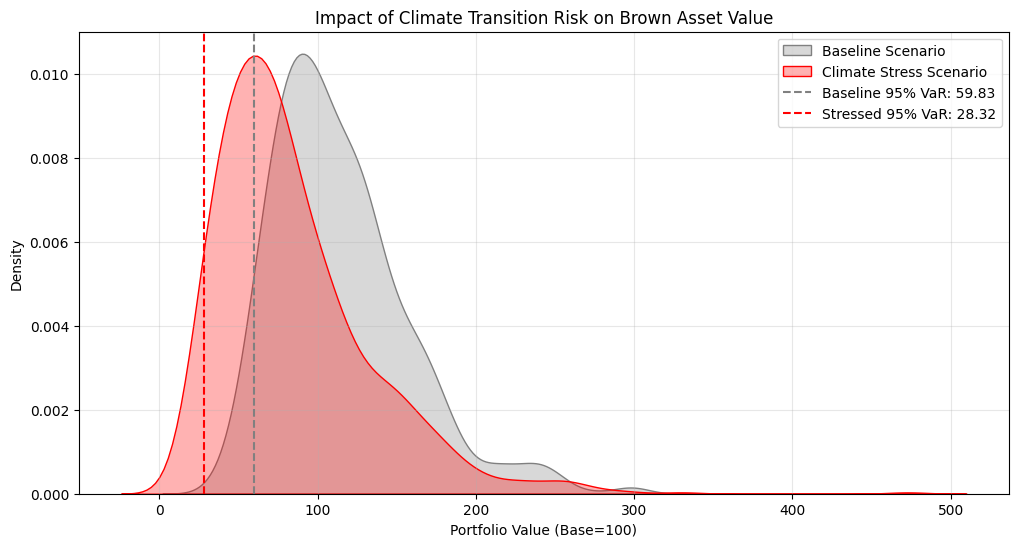


--- Risk Metrics (Unadjusted for Liquidity) ---
Baseline Expected Loss (Mean): -14.38
Stressed Expected Loss (Mean): 15.29


In [2]:
class StressScenarioEngine(MonteCarloEngine):
    def simulate_stressed(self, shocks, T_years=1, n_scenarios=1000, dt=1/252):
        """
        Simulates price paths under a Climate Stress Scenario.
        
        Parameters:
        - shocks: Dictionary containing:
            - 'drift': Dict of additive shocks to annualized returns (e.g., {'Brown': -0.30})
            - 'vol_multiplier': Float to scale volatility (e.g., 1.5 for 50% higher vol)
        """
        n_steps = int(T_years / dt)
        paths = np.zeros((n_scenarios, n_steps + 1, self.n_assets))
        paths[:, 0, :] = 100
        
        # --- 1. Adjust Drift (mu) ---
        # Create a copy of the historical drift
        stressed_mu = self.mu.copy()
        
        # Apply shocks: New Mu = Old Mu + Shock
        print("--- Applying Climate Stress Shocks ---")
        for asset, shock_val in shocks['drift'].items():
            if asset in stressed_mu.index:
                print(f"[!] {asset}: Drift adjusted by {shock_val:+.1%}")
                stressed_mu[asset] += shock_val
        
        # --- 2. Adjust Volatility (Covariance) ---
        # We scale the entire covariance matrix by the multiplier squared
        # (Since Covariance ~ Vol^2)
        vol_mult = shocks.get('vol_multiplier', 1.0)
        print(f"[!] Volatility scaled by {vol_mult}x")
        
        stressed_cov = self.cov_matrix * (vol_mult ** 2)
        
        # Re-calculate Cholesky for the stressed covariance
        L_stressed = np.linalg.cholesky(stressed_cov)
        
        # --- 3. Simulation Loop (Same logic, new parameters) ---
        for t in range(1, n_steps + 1):
            Z_uncorr = np.random.normal(0, 1, size=(n_scenarios, self.n_assets))
            Z_corr = Z_uncorr @ L_stressed.T
            
            # Drift term using STRESSED mu and cov
            drift = (stressed_mu.values - 0.5 * np.diag(stressed_cov)) * dt
            diffusion = Z_corr * np.sqrt(dt)
            
            paths[:, t, :] = paths[:, t-1, :] * np.exp(drift + diffusion)
            
        return paths

# --- Execution ---

# Define the "Disorderly Transition" Scenario
# Hypothesis: Carbon Tax hits Brown assets hard (-30% annual), 
# slight boost to Green (+10%), Market suffers slightly (-5%), Oil drops (-20%).
# Volatility doubles (2.0x) due to panic.

stress_config = {
    'drift': {
        'Brown': -0.30, 
        'Green': +0.10,
        'Market': -0.05,
        'Oil': -0.20
    },
    'vol_multiplier': 1.5
}

# Initialize Stress Engine
stress_engine = StressScenarioEngine(returns_df)

# Run Simulation
stressed_paths = stress_engine.simulate_stressed(stress_config, T_years=1, n_scenarios=1000)

# --- Visualization: Baseline vs. Stressed (Distribution at T=1 year) ---
# We compare the distribution of terminal values (End of Year Prices)

plt.figure(figsize=(12, 6))

# Extract Terminal Prices (Last step)
# Asset Index 3 is 'Brown' (XLE) based on your correlation matrix output order
# Order: Oil (0), Green (1), Market (2), Brown (3)
asset_to_plot = 'Brown'
asset_idx = list(returns_df.columns).index(asset_to_plot)

# Get Baseline Terminal Prices (from previous step)
baseline_terminal = sim_paths[:, -1, asset_idx]
# Get Stressed Terminal Prices
stressed_terminal = stressed_paths[:, -1, asset_idx]

# Plot Histograms (KDE)
sns.kdeplot(baseline_terminal, fill=True, label='Baseline Scenario', color='gray', alpha=0.3)
sns.kdeplot(stressed_terminal, fill=True, label='Climate Stress Scenario', color='red', alpha=0.3)

# Add VaR Lines (5th Percentile)
var_95_base = np.percentile(baseline_terminal, 5)
var_95_stress = np.percentile(stressed_terminal, 5)

plt.axvline(var_95_base, color='gray', linestyle='--', label=f'Baseline 95% VaR: {var_95_base:.2f}')
plt.axvline(var_95_stress, color='red', linestyle='--', label=f'Stressed 95% VaR: {var_95_stress:.2f}')

plt.title(f"Impact of Climate Transition Risk on {asset_to_plot} Asset Value")
plt.xlabel("Portfolio Value (Base=100)")
plt.legend()
plt.grid(True, alpha=0.3)

save_path = os.path.join(PROJECT_ROOT, "outputs", "figures", "stress_test_distribution.png")
plt.savefig(save_path)
print(f"[+] Plot saved to {save_path}")
plt.show()

# Calculate 'Liquidity Gap' (Concept Check)
print(f"\n--- Risk Metrics (Unadjusted for Liquidity) ---")
print(f"Baseline Expected Loss (Mean): {100 - baseline_terminal.mean():.2f}")
print(f"Stressed Expected Loss (Mean): {100 - stressed_terminal.mean():.2f}")